In [1]:
import os
import inspect
n_cores = 4
os.environ["XLA_FLAGS"] = '--xla_force_host_platform_device_count={}'.format(n_cores)

from jax import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import numpy as np
import pickle
from jax import jit, vmap, grad, jacrev
from jax.lax import cond, scan
import jax.random as random
key = random.PRNGKey(2022)
import jax.example_libraries.optimizers as optimizers
from jax.flatten_util import ravel_pytree
from jax.sharding import PositionalSharding
from functools import partial

import matplotlib.pyplot as plt
import pandas as pd

from utils import train, coords_2_strain_nn
from utils import train_colloc_parallel_weak as train_colloc_weak
from utils import train_colloc_parallel as train_colloc,init_params_nn, ff_nn, divergence, bd_forces, a1, a2, lr
from utils_hyperelasticity import NODE, init_layers, NODE_model_aniso, init_params_aniso, GOH_model, eval_Cauchy, eval_Cauchy_vmap, eval_P, eval_P_vmap
from utils_hyperelasticity import ThreeDElasticity
from fem import plotmesh, fe_solver_2D, vahid_anisohyper_inv, apply_bc_biax

from jax_fem.core import FEM
from jax_fem.solver import solver
from jax_fem.utils import save_sol
from jax_fem.generate_mesh import box_mesh, get_meshio_cell_type, Mesh, rectangle_mesh

from PIL import Image, ImageFilter
from jaxinterp2d import interp2d

E_fun = vmap(lambda F: 0.5*(F.T@F - jnp.eye(2)))

       __       ___      ___   ___                _______  _______ .___  ___. 
      |  |     /   \     \  \ /  /               |   ____||   ____||   \/   | 
      |  |    /  ^  \     \  V  /      ______    |  |__   |  |__   |  \  /  | 
.--.  |  |   /  /_\  \     >   <      |______|   |   __|  |   __|  |  |\/|  | 
|  `--'  |  /  _____  \   /  .  \                |  |     |  |____ |  |  |  | 
 \______/  /__/     \__\ /__/ \__\               |__|     |_______||__|  |__| 
                                                                              



## 1. Generate data + pretraining

In [2]:
##########################################################################this is I am using to understand the above code##### skip it when you run the code
print(inspect.getsource(Mesh))

class Mesh():
    """
    A custom mesh manager might be better using a third-party library like
    meshio.
    """
    def __init__(self, points, cells, ele_type='TET4'):
        # TODO: Assert that cells must have correct orders
        # TODO: first cells, then points?
        self.points = points
        self.cells = cells
        self.ele_type = ele_type

    def count_selected_faces(self, location_fn):
        """Given location functions, compute the count of faces that satisfy
        the location function. Useful for setting up distributed load
        conditions.

        Parameters
        ----------
        location_fns : List[Callable]
            Callable: a function that inputs a point and returns a boolean
            value describing whether the boundary condition should be applied.

        Returns
        -------
        face_count : int
        """

        _, _, _, _, face_inds = get_face_shape_vals_and_grads(self.ele_type)
        cell_points = onp.take(self.point

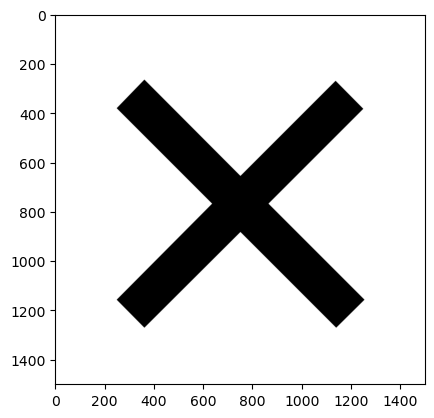

In [3]:
ele_type = 'QUAD4'
cell_type = get_meshio_cell_type(ele_type)
Nx, Ny = 100, 100
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
image = Image.open('×.png')
# image = image.filter(ImageFilter.GaussianBlur(radius=60))
plt.imshow(image)
image = image.rotate(-90)
image = np.array(image)
image = image.mean(axis=2)
image = image/image.max()

pts_x = np.linspace(0,1,image.shape[0])
pts_y = np.linspace(0,1,image.shape[1])

def coords_2_params_gt(xy):
    x, y = xy
    c = interp2d(x,y,pts_x,pts_y,image)
    ##### image size is 1500 by 1500 but the range of values are x,y, pts_x and pts_y are between [0,1]
    return jnp.stack([0.5,0.10,0.20,0.1,0.0]) + c*jnp.stack([0.2,0.02,0.04,0.0,0.0])

In [4]:
GOH_P_vmap = vmap(ThreeDElasticity(GOH_model).ugrad_2_P, in_axes=(0, 0, None))
class HyperElasticity(FEM):
    def get_tensor_map(self):
        return lambda u_grad, params: ThreeDElasticity(GOH_model).ugrad_2_P(u_grad, params, self.dim)
    
    def set_params(self, params_vec):
        self.internal_vars['laplace'] = [params_vec]

In [5]:
##########################################################################this is I am using to understand the above code##### skip it when you run the code
print(GOH_model)
print(inspect.getsource(ThreeDElasticity))

<class 'utils_hyperelasticity.GOH_model'>
class ThreeDElasticity():
    def __init__(self, model):
        self.model = model

    def ugrad_2_P(self, u_grad, params, dim):
        theta = 0.0
        #Kinematics
        F_2D = u_grad + jnp.eye(dim)
        C_2D = F_2D.T @ F_2D
        Cinv_2D = jnp.linalg.inv(C_2D)
        detC_2D = jnp.linalg.det(C_2D)
        C33 = 1/detC_2D
        C = jnp.array([  [C_2D[0,0], C_2D[0,1], 0],\
                        [C_2D[1,0], C_2D[1,1], 0],\
                        [0,         0,       C33]])
        C2 = C @ C
        Cinv = jnp.linalg.inv(C)
        I1 = C[0,0] + C[1,1] + C[2,2]
        trC2 = C2[0,0] + C2[1,1] + C2[2,2]
        I2 = 0.5*(I1**2 - trC2)
        v0 = jnp.array([ jnp.cos(theta), jnp.sin(theta), 0])
        w0 = jnp.array([-jnp.sin(theta), jnp.cos(theta), 0])
        V0 = jnp.outer(v0, v0)
        W0 = jnp.outer(w0, w0)
        Iv = jnp.einsum('ij,ij',C,V0)
        Iw = jnp.einsum('ij,ij',C,W0)

        # Energy/Stress
        mode

In [6]:
ele_type = 'QUAD4'
cell_type = get_meshio_cell_type(ele_type)

Nx, Ny = 50, 50
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
print(mesh)

# Functions to identify the boundary nodes
def bottom(point):
    return jnp.isclose(point[1], 0., atol=1e-5)
def left(point):
    return jnp.isclose(point[0], 0., atol=1e-5)
def top(point):
    return jnp.isclose(point[1], Ly, atol=1e-5)
def right(point):
    return jnp.isclose(point[0], Lx, atol=1e-5)
def bottom_left(point):
    return jnp.logical_and(jnp.logical_and(bottom(point), left(point)), jnp.isclose(point[2], 0., atol=1e-5))


# Functions to assign dirichlet BCs
def zero_dirichlet(point):
    return 0.
def lmbx_max_dirichlet(point, lmbx_max):
    return Lx*lmbx_max - 1.0
def lmby_max_dirichlet(point, lmby_max):
    return Ly*lmby_max - 1.0


lmb_hist = [1.05, 1.10, 1.15, 1.20]
n_elem = Nx*Ny
F_hist_goh = []
P_hist_goh = []
for lmb_max in lmb_hist:
    dirichlet_bc_info = [
        [bottom,            left,           top,                                        right,                                  ],
        [1,                 0,              1,                                          0,                                      ],
        [zero_dirichlet,    zero_dirichlet, lambda p: lmby_max_dirichlet(p, lmb_max),   lambda p: lmbx_max_dirichlet(p, lmb_max)]
    ]
    problem = HyperElasticity(mesh,
                            vec=2,
                            dim=2,
                            ele_type=ele_type,
                            dirichlet_bc_info=dirichlet_bc_info)
    elem_X = problem.get_physical_quad_points().mean(1)

    # params = vmap(coords_2_params_gt)(elem_X)
    params = []
    for xy in elem_X:
        params.append(coords_2_params_gt(xy))
    params = np.expand_dims(params, 1)
    params_vec = jnp.repeat(params, axis=1, repeats=4)
    problem.set_params(params_vec)


    u = solver(problem, use_petsc=True)
    u_grad = np.mean(problem.sol_to_grad(u), axis=1)
    F = u_grad + np.eye(2)

    P = GOH_P_vmap(u_grad, params_vec[:,0,:], 2)
    
    F_hist_goh.append(F)
    P_hist_goh.append(P)
F_hist_goh = np.array(F_hist_goh)
P_hist_goh = np.array(P_hist_goh)

[09-16 13:09:50][DEBUG] jax_fem: Computing shape function values, gradients, etc.
[09-16 13:09:50][DEBUG] jax_fem: ele_type = QUAD4, quad_points.shape = (num_quads, dim) = (4, 2)
[09-16 13:09:50][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (4, 2, 2)


[09-16 13:09:51][DEBUG] jax_fem: Done pre-computations, took 0.9413106441497803 [s]
[09-16 13:09:51][INFO] jax_fem: Solving a problem with 2500 cells, 2601x2 = 5202 dofs.
[09-16 13:09:53][DEBUG] jax_fem: Calling the row elimination solver for imposing Dirichlet B.C.
[09-16 13:09:53][DEBUG] jax_fem: Start timing
[09-16 13:09:53][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[09-16 13:09:55][DEBUG] jax_fem: Function split_and_compute_cell took 1.5953 seconds
[09-16 13:09:56][DEBUG] jax_fem: Creating sparse matrix with scipy...
[09-16 13:09:56][DEBUG] jax_fem: Linear guess solve...
[09-16 13:09:56][DEBUG] jax_fem: PETSc - Solving with ksp_type = bcgsl, pc = ilu
[09-16 13:09:56][DEBUG] jax_fem: PETSc linear solve res = 2.922363883893081e-06
[09-16 13:09:56][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[09-16 13:09:56][DEBUG] jax_fem: Function split_and_compute_cell took 0.0412 seconds
[09-16 13:09:56][DEBUG] jax_fem: Creating sparse matrix with scipy...
[09-1

(2500, 2)
(2500, 2)
(2500, 2)
(2500, 2)


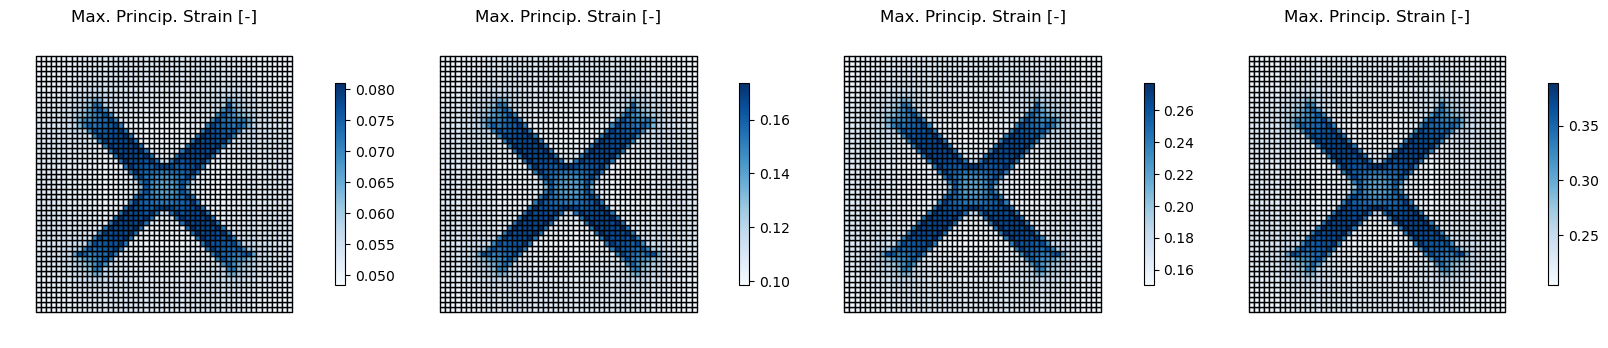

In [7]:
fig, axes = plt.subplots(1,4,figsize=(20,4))
strains = []
t_hist = np.arange(len(lmb_hist))
for t, F, P, ax in zip(t_hist, F_hist_goh, P_hist_goh, axes):
    E = E_fun(F)
    evals, efuns = jnp.linalg.eigh(E)
    print(evals.shape)
    E_11, E_22 = evals.T

    mps = np.maximum(E_11, E_22)
    plotmesh(mesh.cells, mesh.points, mps, title='Max. Princip. Strain [-]', ax=ax); 

    strains.append(np.array([t*np.ones(len(F)), F[:,0,0], F[:,0,1], F[:,1,0], F[:,1,1]]))
strains = np.hstack(strains)

### Coords_2_strain NN

In [37]:
# instead of using a 2D spline, use a NN to get the strain field for a given (x,y)
def loss_coords_2_strain(params, X, key):
    inp, out_gt = X[:,:3], X[:,3:] #inp: x,y,lmb and out_gt=eps_xx, eps_yy
    t = inp[:,2:3]
    out_pr = coords_2_strain_nn(inp, params)
    out_gt = out_gt/(t+1) #dividing by t+1 just for some regularization
    out_pr = out_pr/(t+1) #dividing by t+1 just for some regularization
    return jnp.mean((out_pr-out_gt)**2)

n_ff = 40 # 10 cosines and 10 sines in the fourier features
n_inp = 2 # x, y
ff_params = np.random.normal(size=n_inp*n_ff).reshape([n_inp,n_ff])*0.5
nn_layers = [2*n_ff+1,40,40,4]
nn_params = init_params_nn(nn_layers, key)
coord_2_strain_params = [ff_params, nn_params]

opt_init, opt_update, get_params = optimizers.adam(5.e-4)
opt_state = opt_init(coord_2_strain_params)

X = np.vstack([elem_X, elem_X, elem_X, elem_X])
inp = np.hstack([X, strains.T])
coord_2_strain_params, train_loss, _ = train(loss_coords_2_strain, inp, get_params, opt_update, opt_state, key, nIter = 100000, print_freq=1000, batch_size=1000)

it 1000, train loss = 1.108865e-04
it 2000, train loss = 4.933875e-05
it 3000, train loss = 3.081963e-05
it 4000, train loss = 2.606622e-05
it 5000, train loss = 2.054833e-05
it 6000, train loss = 1.819996e-05
it 7000, train loss = 1.695233e-05
it 8000, train loss = 1.699933e-05
it 9000, train loss = 1.577943e-05
it 10000, train loss = 1.276484e-05
it 11000, train loss = 1.160755e-05
it 12000, train loss = 1.229830e-05
it 13000, train loss = 1.081543e-05
it 14000, train loss = 1.010851e-05
it 15000, train loss = 9.599940e-06
it 16000, train loss = 8.712452e-06
it 17000, train loss = 9.764769e-06
it 18000, train loss = 8.242312e-06
it 19000, train loss = 9.183200e-06
it 20000, train loss = 7.916943e-06
it 21000, train loss = 6.868844e-06
it 22000, train loss = 7.171182e-06
it 23000, train loss = 7.428576e-06
it 24000, train loss = 7.201992e-06
it 25000, train loss = 6.646024e-06
it 26000, train loss = 9.222557e-06
it 27000, train loss = 7.209518e-06
it 28000, train loss = 5.706056e-06
i

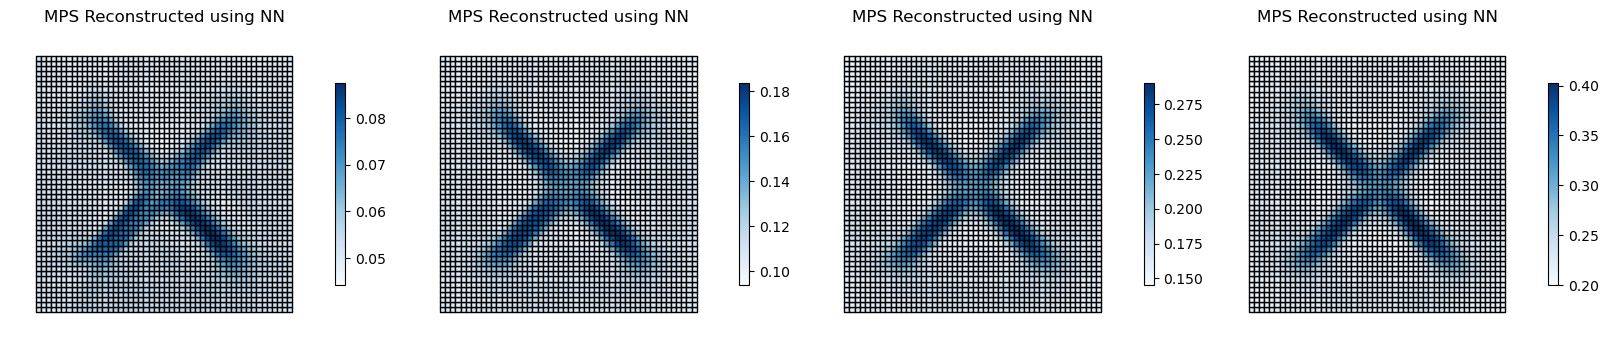

In [9]:
fig, axes = plt.subplots(1,4,figsize=(20,4))
for t in t_hist:
    ax = axes[t]
    aux = np.hstack([elem_X, t*np.ones_like(elem_X[:,:1])])
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn(aux, coord_2_strain_params).T
    F = np.stack([F_xx, F_xy, F_yx, F_yy]).T.reshape([-1,2,2])
    
    E = E_fun(F)
    evals, efuns = jnp.linalg.eigh(E)
    E_11, E_22 = evals.T
    mps = np.maximum(E_11, E_22)

    plotmesh(mesh.cells, mesh.points, mps, title='MPS Reconstructed using NN', ax=ax); 

In [10]:
# identify the boundaries
rgt_bd_elems = []
top_bd_elems = []
lft_bd_elems = []
bot_bd_elems = []
for i, e in enumerate(mesh.cells):
    if any([mesh.points[e[i],0]>0.99 for i in range(4)]):
        rgt_bd_elems.append(i)
    if any([mesh.points[e[i],1]>0.99 for i in range(4)]):
        top_bd_elems.append(i)
    if any([mesh.points[e[i],0]<0.01 for i in range(4)]):
        lft_bd_elems.append(i)
    if any([mesh.points[e[i],1]<0.01 for i in range(4)]):
        bot_bd_elems.append(i)

# get the reaction forces by integrating the stresses of the boundary elements
rgt_bd_frc = np.sum(P_hist_goh[:,rgt_bd_elems,0,0], axis=1)
lft_bd_frc = np.sum(P_hist_goh[:,lft_bd_elems,0,0], axis=1)
top_bd_frc = np.sum(P_hist_goh[:,top_bd_elems,1,1], axis=1)
bot_bd_frc = np.sum(P_hist_goh[:,bot_bd_elems,1,1], axis=1)
Force_x = jnp.array(0.5*(rgt_bd_frc + lft_bd_frc))
Force_y = jnp.array(0.5*(top_bd_frc + bot_bd_frc))

# get the center points of the elements
rgt_bd_X = elem_X[rgt_bd_elems]
top_bd_X = elem_X[top_bd_elems]
lft_bd_X = elem_X[lft_bd_elems]
bot_bd_X = elem_X[bot_bd_elems]
bd_X = rgt_bd_X, top_bd_X, lft_bd_X, bot_bd_X

In [11]:
print(rgt_bd_frc)
print(lft_bd_frc)
print(top_bd_frc )
print(bot_bd_frc)
print(elem_X.shape)
print(bd_X)

[18.14959 32.9266  45.34941 56.13861]
[18.14959 32.9266  45.34941 56.13861]
[17.51077 31.50322 42.98091 52.64213]
[17.51077 31.50322 42.98091 52.64214]
(2500, 2)
(array([[0.99, 0.01],
       [0.99, 0.03],
       [0.99, 0.05],
       [0.99, 0.07],
       [0.99, 0.09],
       [0.99, 0.11],
       [0.99, 0.13],
       [0.99, 0.15],
       [0.99, 0.17],
       [0.99, 0.19],
       [0.99, 0.21],
       [0.99, 0.23],
       [0.99, 0.25],
       [0.99, 0.27],
       [0.99, 0.29],
       [0.99, 0.31],
       [0.99, 0.33],
       [0.99, 0.35],
       [0.99, 0.37],
       [0.99, 0.39],
       [0.99, 0.41],
       [0.99, 0.43],
       [0.99, 0.45],
       [0.99, 0.47],
       [0.99, 0.49],
       [0.99, 0.51],
       [0.99, 0.53],
       [0.99, 0.55],
       [0.99, 0.57],
       [0.99, 0.59],
       [0.99, 0.61],
       [0.99, 0.63],
       [0.99, 0.65],
       [0.99, 0.67],
       [0.99, 0.69],
       [0.99, 0.71],
       [0.99, 0.73],
       [0.99, 0.75],
       [0.99, 0.77],
       [0.99, 0.79

In [ ]:
# Homogenize the strains
F_xx_mean = np.mean(F_hist_goh[:,:,0,0], axis=1)
F_xy_mean = np.mean(F_hist_goh[:,:,0,1], axis=1)
F_yx_mean = np.mean(F_hist_goh[:,:,1,0], axis=1)
F_yy_mean = np.mean(F_hist_goh[:,:,1,1], axis=1)

P_xx_mean = Force_x/len(rgt_bd_elems)
P_yy_mean = Force_y/len(top_bd_elems)
inputs = np.array([F_xx_mean, F_xy_mean, F_yx_mean, F_yy_mean, P_xx_mean, P_yy_mean]).T

n_neurons = 4
# Define the loss function for when training all params
@jit
def loss_stress(params, x, key):
    model = NODE_model_aniso(params)
    F_xx, F_xy, F_yx, F_yy, P_xx_gt, P_yy_gt = x.T
    P = eval_P_vmap(F_xx, F_xy, F_yx, F_yy, model)
    P_xx_pr, P_yy_pr = P[:,0,0], P[:,1,1]
    return np.mean((P_xx_pr-P_xx_gt)**2+(P_yy_pr-P_yy_gt)**2)

# Initialize NODEs and the optimizer
key = random.PRNGKey(0)
common_layers = [1, n_neurons, n_neurons]
sample_layers = [n_neurons,1]
node_params = init_params_aniso(common_layers, sample_layers, key)
opt_init, opt_update, get_params = optimizers.adam(5.e-4) #Original: 1.e-4
opt_state = opt_init(node_params)

# Train
node_params, train_loss, _ = train(loss_stress, inputs, get_params, opt_update, opt_state, key, nIter = 20000, print_freq=1000)

In [58]:
#print(inspect.getsource(NODE_model_aniso))
print(type(node_params[0]))
print(inputs.shape)#Λ 
print(common_layers )
print(sample_layers)

<class 'tuple'>
(4, 6)
[1, 4, 4]
[4, 1]


In [16]:
mymodel = NODE_model_aniso(node_params)
P = eval_P_vmap(F_xx_mean, F_xy_mean, F_yx_mean, F_yy_mean, mymodel)
P_xx_pr, P_yy_pr = P[:,0,0], P[:,1,1]
print('gt P_xx & P_yy: ', P_xx_mean, P_yy_mean)
print('pr P_xx & P_yy: ', P_xx_pr, P_yy_pr)

gt P_xx & P_yy:  [0.36299 0.65853 0.90699 1.12277] [0.35022 0.63006 0.85962 1.05284]
pr P_xx & P_yy:  [0.36164 0.66095 0.90507 1.12334] [0.34896 0.63248 0.85758 1.05347]


In [62]:
# Fit a function Λ that maps x,y ∈ [0,1] to the individual-specific parameters of this NODE with a maximum variance of, say, 1%
phi, unravel = ravel_pytree(node_params)
n_phi = len(phi)

# ff_params = coord_2_sΛ train_params[0]
# ff_nn2 = lambda x, nn_params: ff_nn(x, [ff_params, nn_params])
def loss_Lambda(params, inp, key):
    out_pr = ff_nn(inp, params)
    return jnp.mean((out_pr-phi)**2)

n_ff = 40
ff_params = np.random.normal(size=2*n_ff).reshape([2,n_ff])
nn_layers = [2*n_ff,40,40,n_phi]
nn_params = init_params_nn(nn_layers, key)
Lambda_params = [ff_params, nn_params]
opt_init, opt_update, get_params = optimizers.adam(5.e-4) #Original: 1.e-4
opt_state = opt_init(Lambda_params)

inp = np.array(np.meshgrid(np.linspace(0,1,20), np.linspace(0,1,20))).reshape([2,-1]).T
Lambda_params, train_loss, _ = train(loss_Lambda, inp, get_params, opt_update, opt_state, key, nIter = 5000, print_freq=1000)

it 1000, train loss = 1.439497e-04
it 2000, train loss = 4.117763e-05
it 3000, train loss = 1.738574e-05
it 4000, train loss = 8.551400e-06
it 5000, train loss = 4.523801e-06


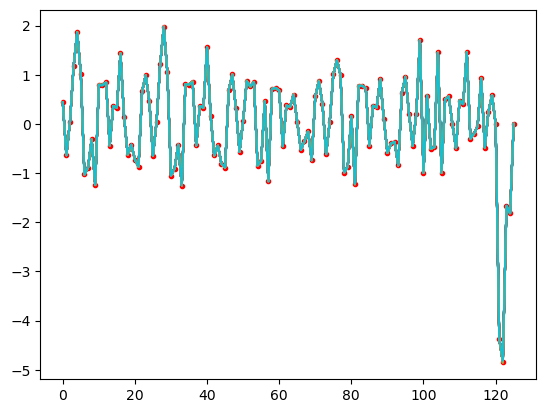

In [11]:
phi, unravel = ravel_pytree(node_params)
fig, ax = plt.subplots()
ax.plot(phi, 'r.-')
for y in np.linspace(0,1,4):
    for x in np.linspace(0,1,10):
        params = ff_nn(np.array([x,y]).reshape([1,-1]), Lambda_params)
        ax.plot(params[0])

In [ ]:
# with open('params/×_sharp_pre.npy', 'wb') as f:
#     pickle.dump([coord_2_strain_params, node_params, Lambda_params, mesh, elem_X, Force_x, Force_y, strains,
#                  bd_X, lmb_hist, P_hist_goh, F_hist_goh, t_hist], f)

In [8]:
with open('params/×_sharp_pre.npy', 'rb') as f:
    coord_2_strain_params, node_params, Lambda_params, mesh, elem_X, Force_x, Force_y, strains, \
                 bd_X, lmb_hist, P_hist_goh, F_hist_goh, t_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))
coords_2_strain_nn_ff = lambda x, params: coords_2_strain_nn(x, params)
ff_nn_ff = lambda x, params: ff_nn(x, params)

In [12]:
def get_P(X, Y, t, Lambda_params, coord_2_strain_params, model):
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn_ff(jnp.array([X,Y,t])[None,:], coord_2_strain_params).flatten()
    # get NODE individual-specific params, phi, from the Lambda NN
    Lambda_inp = jnp.array([X,Y]).reshape([-1,2])
    phi = ff_nn_ff(Lambda_inp, Lambda_params).flatten()
    # Make predictions with this NODE
    ugrad = jnp.array([[F_xx-1.0, F_xy],[F_yx, F_yy-1.0]])
    P = ThreeDElasticity(model).ugrad_2_P(ugrad, phi, 2)
    return P[0,0], P[1,0], P[0,1], P[1,1]
get_P_vmap = vmap(get_P, in_axes=(0,0,0,None,None,None), out_axes=(0,0,0,0))

get_Pxx = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[0]
get_Pyx = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[1]
get_Pxy = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[2]
get_Pyy = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[3]

Grad_Pxx_X = vmap(grad(get_Pxx, argnums=0), in_axes=(0,0,0,None,None,None), out_axes=0) # should return dsgm_xx/dx
Grad_Pyx_X = vmap(grad(get_Pyx, argnums=0), in_axes=(0,0,0,None,None,None), out_axes=0)
Grad_Pxy_Y = vmap(grad(get_Pyx, argnums=1), in_axes=(0,0,0,None,None,None), out_axes=0)
Grad_Pyy_Y = vmap(grad(get_Pyy, argnums=1), in_axes=(0,0,0,None,None,None), out_axes=0)

@partial(jit, static_argnums=(4,))
def bd_forces(Lambda_params, t, bd_X, c2s_params, model):
    rgt_bd_X, top_bd_X, lft_bd_X, bot_bd_X = bd_X
    rgt_bd_P = get_P_vmap(rgt_bd_X[:,0], rgt_bd_X[:,1], t*jnp.ones_like(rgt_bd_X[:,0]), Lambda_params, c2s_params, model)
    top_bd_P = get_P_vmap(top_bd_X[:,0], top_bd_X[:,1], t*jnp.ones_like(top_bd_X[:,0]), Lambda_params, c2s_params, model)
    lft_bd_P = get_P_vmap(lft_bd_X[:,0], lft_bd_X[:,1], t*jnp.ones_like(lft_bd_X[:,0]), Lambda_params, c2s_params, model)
    bot_bd_P = get_P_vmap(bot_bd_X[:,0], bot_bd_X[:,1], t*jnp.ones_like(bot_bd_X[:,0]), Lambda_params, c2s_params, model)

    rgt_bd_frc = jnp.sum(rgt_bd_P[0]*1.0) # Assume area of edge = 1.0
    top_bd_frc = jnp.sum(top_bd_P[3]*1.0)
    lft_bd_frc = jnp.sum(lft_bd_P[0]*1.0)
    bot_bd_frc = jnp.sum(bot_bd_P[3]*1.0)
    return rgt_bd_frc, top_bd_frc, lft_bd_frc, bot_bd_frc

@partial(jit, static_argnums=(3,))
def divergence(Lambda_params, XYt, c2s_params, model):
    dPxx_dX = Grad_Pxx_X(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPxy_dY = Grad_Pxy_Y(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPyx_dX = Grad_Pyx_X(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPyy_dY = Grad_Pyy_Y(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    
    Div_X = jnp.mean(dPxx_dX + dPxy_dY)
    Div_Y = jnp.mean(dPyx_dX + dPyy_dY)
    return Div_X, Div_Y
#%%
# Train
a1 = 10000
@jit
def loss(Lambda_params, XYt_colloc):

    P_pred = get_P_vmap(XYt_colloc[:,0],XYt_colloc[:,1], XYt_colloc[:,2], Lambda_params, coord_2_strain_params, NODE_w_unravel)
    P_xx = P_xx_mean[jnp.array(XYt_colloc[:,2], int)]
    P_yy = P_yy_mean[jnp.array(XYt_colloc[:,2], int)]

    loss_P = jnp.mean((P_pred[0] - P_xx)**2 + (P_pred[3] - P_yy)**2)
    # loss_F = 0.0
    
    return loss_P

lr = optimizers.exponential_decay(1e-3, 10000, 0.9)
sharding = PositionalSharding(jax.devices()).reshape(n_cores, 1)
opt_init, opt_update, get_params = optimizers.adam(lr) 
opt_state = opt_init(Lambda_params)

node_X_ext = jnp.hstack([mesh.points, t_hist[-1]*np.ones_like(mesh.points[:,:1])])
metric1 = lambda params, X:  bd_forces(params, t_hist[-1], bd_X, coord_2_strain_params, NODE_w_unravel)
metric2 = lambda params, X: divergence(params, node_X_ext, coord_2_strain_params, NODE_w_unravel)

# Lambda_params, val_loss, metrics = train_colloc(loss, [mesh.points, t_hist], get_params, opt_update, opt_state, 
#                                             key, sharding, 'cross', nIter = 30000, print_freq=1000, batch_size=1000)

In [57]:
with open('×_paper_second_pretraining.pickle', 'rb') as f:
    Lambda_params,val_loss, metrics=pickle.load(f)

## Weak form formulation
$\sum\limits_{n = 1}^2 {\sum\limits_{j = 1}^2 {P_{ij}^{(n)}\int\limits_\Omega  {{N_{(n)}}{N_{(m),j}}} }  } -\sum\limits_{n = 1}^2 {t_i^{(n)}\int\limits_{{\Omega t}} {{N{(n)}}{N_{(m)}}} }  = 0$

In [58]:
def generate_q4_mesh(Lx, Ly, nx, ny):
    xs = np.linspace(0.0, Lx, nx + 1)
    ys = np.linspace(0.0, Ly, ny + 1)

    nodes = []
    for i, x in enumerate(xs):      
        for j, y in enumerate(ys):  
            nodes.append([x, y])
    nodes = np.array(nodes, dtype=float)

    grid = np.arange((nx + 1) * (ny + 1), dtype=int).reshape(nx + 1, ny + 1).T


    conn = []
    for i in range(nx):      
        for j in range(ny):  
            bl = grid[j,   i  ]   
            br = grid[j,   i+1]   
            tr = grid[j+1, i+1]  
            tl = grid[j+1, i  ]   
            conn.append([bl, br, tr, tl])

    return nodes, np.asarray(conn, dtype=int), grid

def get_side_nodes(grid):
    left   = grid[:, 0]
    right  = grid[:, -1]
    bottom = grid[0, :]
    top    = grid[-1, :]
    return left, right, top, bottom

def side_nodes(grid, side):
   
    side = side.lower()
    if side == "left":   return grid[:, 0]
    if side == "right":  return grid[:, -1]
    if side == "bottom": return grid[0, :]
    if side in ("top", "up"): return grid[-1, :]
    raise ValueError("side must be one of: 'left','right','bottom','top' (or 'up').")

_gauss_pts = np.array([[-1/np.sqrt(3), -1/np.sqrt(3)],
                       [ 1/np.sqrt(3), -1/np.sqrt(3)],
                       [ 1/np.sqrt(3),  1/np.sqrt(3)],
                       [-1/np.sqrt(3),  1/np.sqrt(3)]])
_gauss_wts = np.ones(4)

def shape_Q4(ξ, η):
    N1 = 0.25*(1-ξ)*(1-η)
    N2 = 0.25*(1+ξ)*(1-η)
    N3 = 0.25*(1+ξ)*(1+η)
    N4 = 0.25*(1-ξ)*(1+η)
    dN_dξ = np.array([-(1-η), (1-η), (1+η), -(1+η)])*0.25
    dN_dη = np.array([-(1-ξ), -(1+ξ), (1+ξ),  (1-ξ)])*0.25
    return np.array([N1, N2, N3, N4]), dN_dξ, dN_dη

def assemble_NNgrad_and_load(nodes, conn):
    Nn = nodes.shape[0]
    K_G = np.zeros((Nn, 2*Nn))

    for e, enodes in enumerate(conn):
        xe = nodes[enodes, 0]
        ye = nodes[enodes, 1]
        K_e  = np.zeros((4, 8))

        for (ξ,η), w in zip(_gauss_pts, _gauss_wts):
            N, dN_dξ, dN_dη = shape_Q4(ξ, η)
            x_ξ = np.dot(dN_dξ, xe); x_η = np.dot(dN_dη, xe)
            y_ξ = np.dot(dN_dξ, ye); y_η = np.dot(dN_dη, ye)
            J = np.array([[x_ξ, x_η],
                          [y_ξ, y_η]])
            detJ = np.linalg.det(J)
            invJ = np.linalg.inv(J)

            dN = np.vstack([dN_dξ, dN_dη])   
            dN_phys = invJ @ dN               
            dN_dx = dN_phys[0, :]
            dN_dy = dN_phys[1, :]

            wJ = w * detJ
         
            K_e  += np.hstack((np.outer(dN_dx, N) * wJ,
                               np.outer(dN_dy, N) * wJ))
        row_idx = enodes
        col_idx = np.r_[enodes, enodes + Nn]
        K_G[np.ix_(row_idx, col_idx)] += K_e

    return K_G

def assemble_boundary_traction_side(nodes, grid, t1_nodes, t2_nodes):
    t1_vals = np.asarray(t1_nodes, dtype=float)
    t2_vals = np.asarray(t2_nodes, dtype=float)
    Nn  = nodes.shape[0]
    f1_side = np.zeros(Nn)
    f2_side = np.zeros(Nn)
    sides=[ "left","right", "bottom","top"]
    for i, side in enumerate(sides):
        ids = np.asarray(side_nodes(grid, side))
        Ns  = len(ids)
        for k in range(Ns - 1):
            a = ids[k]; b = ids[k + 1]
            xa, ya = nodes[a]
            xb, yb = nodes[b]
            L = np.hypot(xb - xa, yb - ya)

            Me = (L / 6.0) * np.array([[2.0, 1.0],
                                    [1.0, 2.0]])

            f1_local = Me @ np.array([t1_vals[a], t1_vals[b]])
            f2_local = Me @ np.array([t2_vals[a], t2_vals[b]])

            f1_side[a] += f1_local[0]; f1_side[b] += f1_local[1]
            f2_side[a] += f2_local[0]; f2_side[b] += f2_local[1]

    return f1_side, f2_side
def side_length(Lx, Ly, side):
    """Geometric length of a boundary side in the rectangle."""
    s = side.lower()
    if s in ("left", "right"):
        return Ly
    if s in ("bottom", "top", "up"):
        return Lx
    raise ValueError("side must be one of: 'left','right','bottom','top' (or 'up').")

def distribute_reactions_to_tractions(grid, Lx, Ly, reactions_dict):
    N = grid.size
    tx = np.zeros(N)
    ty = np.zeros(N)
    info = {}

    for side, F in reactions_dict.items():
        F = np.asarray(F, dtype=float)   # [Fx, Fy]
        nodes_on_side = side_nodes(grid, side)
        Ns = nodes_on_side.size
        Ls = side_length(Lx, Ly, side)
        t_node = F / (Ls)

        tx[nodes_on_side] += t_node[0]
        ty[nodes_on_side] += t_node[1]

        info[side.lower()] = {
            "count": int(Ns),
            "length": float(Ls),
            "t_per_side": t_node.copy(),
            "node_ids": nodes_on_side.copy(),
        }

    return tx, ty, info

In [59]:
Lx, Ly = 1.0, 1.0
nx, ny = 30,30
nodes, conn, grid = generate_q4_mesh(Lx, Ly, nx, ny)
K_G= assemble_NNgrad_and_load(nodes, conn)
rgt_bd_frc_w=np.vstack((rgt_bd_frc, np.zeros_like(rgt_bd_frc)))
lft_bd_frc_w=np.vstack((-lft_bd_frc, np.zeros_like(lft_bd_frc)))
top_bd_frc_w=np.vstack((np.zeros_like(top_bd_frc),top_bd_frc))
bot_bd_frc_w=np.vstack((np.zeros_like(bot_bd_frc),-bot_bd_frc))
print(rgt_bd_frc_w)
print(lft_bd_frc_w)
print(top_bd_frc_w)
print(bot_bd_frc_w)
tx_hist=[]
ty_hist=[]
meta_hist=[]
for i in range(len(t_hist)): 
    print(i) 
    reactions = {
            "left":   lft_bd_frc_w[:,i],   # N (total)
            "right":  rgt_bd_frc_w[:,i],
            "bottom":bot_bd_frc_w[:,i],
            "top": top_bd_frc_w[:,i],
        }
    tx, ty, meta = distribute_reactions_to_tractions( grid, Lx, Ly, reactions)
    f1_edge, f2_edge = assemble_boundary_traction_side(nodes, grid, tx,ty)
    tx_hist.append(f1_edge)
    ty_hist.append(f2_edge)
    meta_hist.append(meta)
tx_hist = jnp.stack([jnp.array(f) for f in tx_hist], axis=0)
ty_hist = jnp.stack([jnp.array(f) for f in ty_hist], axis=0)
def get_P(X, Y, t, Lambda_params, coord_2_strain_params, model):
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn_ff(jnp.array([X,Y,t])[None,:], coord_2_strain_params).flatten()
    # get NODE individual-specific params, phi, from the Lambda NN
    Lambda_inp = jnp.array([X,Y]).reshape([-1,2])
    phi = ff_nn_ff(Lambda_inp, Lambda_params).flatten()
    # Make predictions with this NODE
    ugrad = jnp.array([[F_xx-1.0, F_xy],[F_yx, F_yy-1.0]])
    P = ThreeDElasticity(model).ugrad_2_P(ugrad, phi, 2)
    return P[0,0], P[0,1], P[1,0], P[1,1]
get_P_vmap = vmap(get_P, in_axes=(0,0,0,None,None,None), out_axes=(0,0,0,0))
def loss_weak_form(Lambda_params,spatial_temporal_address,K_G,tx_hist,ty_hist, c2s_params, model):
    first_eqs=[]
    second_eqs=[]
    for ii in range(len(t_hist)):
        XYt = jnp.hstack([nodes, t_hist[ii]*np.ones((nodes.shape[0],1))]) 
        Ps_time=jnp.array(get_P_vmap(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model))
        for_first_eq=K_G @ jnp.vstack((Ps_time[[0],:].T,Ps_time[[1],:].T))
        for_second_eq=K_G @ jnp.vstack((Ps_time[[2],:].T,Ps_time[[3],:].T))
        first_eqs.append(jnp.squeeze(for_first_eq.T))
        second_eqs.append(jnp.squeeze(for_second_eq.T))
    first_eqs=jnp.stack(first_eqs, axis=0)
    second_eqs=jnp.stack(second_eqs, axis=0)
    spatial_idx = spatial_temporal_address[:, 0]
    time_idx    = spatial_temporal_address[:, 1]
    eps=10**-3
    alpha=10000
    tx_colle = tx_hist[time_idx,spatial_idx]
    first_eqs_colle=first_eqs[time_idx,spatial_idx]
    ty_colle = ty_hist[time_idx,spatial_idx]
    second_eqs_colle=second_eqs[time_idx,spatial_idx]
    w1 = jnp.where(jnp.abs(tx_colle) < eps, alpha, 1.0)
    w2 = jnp.where(jnp.abs(ty_colle) < eps, alpha, 1.0)
    loss1 = jnp.sum(w1 * (first_eqs_colle- - tx_colle)**2)
    loss2 = jnp.sum(w2 * (second_eqs_colle- ty_colle)**2)
    return loss1+loss2


[[18.14959 32.9266  45.34941 56.13861]
 [ 0.       0.       0.       0.     ]]
[[-18.14959 -32.9266  -45.34941 -56.13861]
 [  0.        0.        0.        0.     ]]
[[ 0.       0.       0.       0.     ]
 [17.51077 31.50322 42.98091 52.64213]]
[[  0.        0.        0.        0.     ]
 [-17.51077 -31.50322 -42.98091 -52.64214]]
0
1
2
3


## 2. Retrain

In [ ]:

@jit
def loss_weak_main(Lambda_params, XYt_colloc,spatial_temporal_address):
    
    loss_w=loss_weak_form(Lambda_params,spatial_temporal_address,K_G,tx_hist,ty_hist,coord_2_strain_params, NODE_w_unravel)
    
    return loss_w

lr = 1e-4
sharding = PositionalSharding(jax.devices()).reshape(n_cores, 1)
opt_init, opt_update, get_params = optimizers.adam(lr) 
opt_state = opt_init(Lambda_params)

node_X_ext = jnp.hstack([mesh.points, t_hist[-1]*np.ones_like(mesh.points[:,:1])])
metric1 = lambda params, X:  bd_forces(params, t_hist[-1], bd_X, coord_2_strain_params, NODE_w_unravel)
metric2 = lambda params, X: divergence(params, node_X_ext, coord_2_strain_params, NODE_w_unravel)
Lambda_params, val_loss, metrics = train_colloc_weak(loss_weak_main, [nodes, t_hist], get_params, opt_update, opt_state, 
                                            key, sharding, 'cross', nIter = 40000, print_freq=1000, batch_size=1000)

# with open('params/×_sharp_post.npy', 'wb') as f:
#     pickle.dump([mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist], f)

## 3. Test

In [6]:
with open('params/×_sharp_post.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

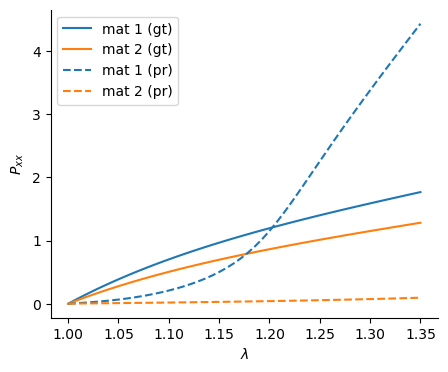

In [55]:
mat1_params = coords_2_params_gt([0.0,0.0])
mat2_params = coords_2_params_gt([0.5,0.5])
mat1_P_gt = []
mat2_P_gt = []
mat1_P_pr = []
mat2_P_pr = []
# lmb_hist2 = [1.0, 1.005, 1.01, 1.02, 1.03, 1.04, 1.05, 1.10, 1.15, 1.20, 1.25, 1.30, 1.35]
lmb_hist2 = np.linspace(1,1.35)
for lmb in lmb_hist2:
    ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])
    mat1_P_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat1_params, 2)[0,0])
    mat2_P_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat2_params, 2)[0,0])

    mat1_params_pr = ff_nn(np.array([0.0, 0.0]), Lambda_params)
    mat2_params_pr = ff_nn(np.array([0.5, 0.5]), Lambda_params)
    mat1_P_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, mat1_params_pr, 2)[0,0])
    mat2_P_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, mat2_params_pr, 2)[0,0])

fig, ax = plt.subplots(figsize=(5,4))
ax.plot(lmb_hist2, mat1_P_gt, label='mat 1 (gt)')
ax.plot(lmb_hist2, mat2_P_gt, label='mat 2 (gt)')

fig.gca().set_prop_cycle(None)
ax.plot(lmb_hist2, mat1_P_pr, '--', label='mat 1 (pr)')
ax.plot(lmb_hist2, mat2_P_pr, '--', label='mat 2 (pr)')

ax.legend()
ax.set(xlabel='$\lambda$', ylabel='$P_{xx}$')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

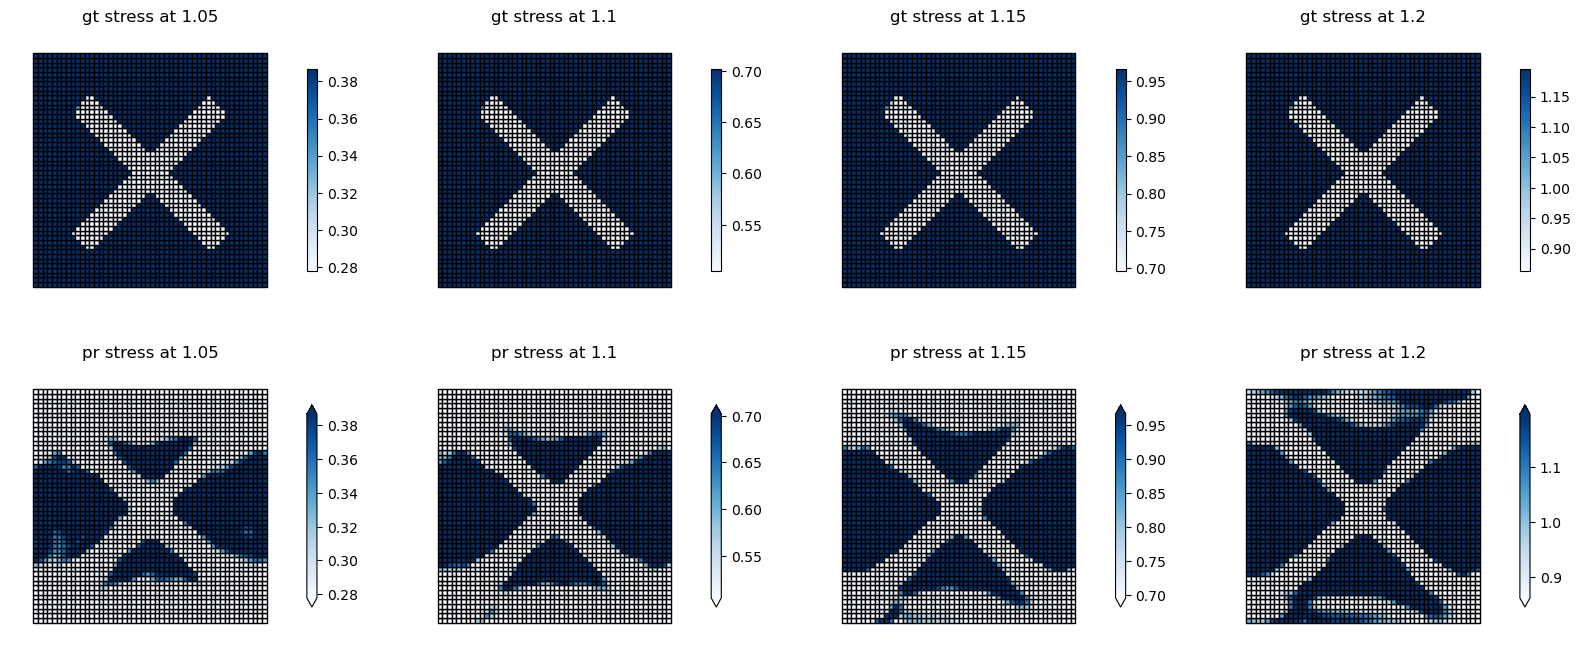

In [56]:
# Stiffness across the domain
fig, axes = plt.subplots(2,4,figsize=(20,8))
for lmb, ax in zip(lmb_hist, axes.T):
    ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])

    params_gt = []
    for xy in elem_X:
        params_gt.append(coords_2_params_gt(xy))
    params_gt = np.array(params_gt)
    params_pr = ff_nn(elem_X, Lambda_params)

    c_elem_gt = []
    c_elem_pr = []
    for params_gt_i, params_pr_i in zip(params_gt, params_pr):
        c_elem_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, params_gt_i, 2)[0,0])
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[0,0])
    
    plotmesh(mesh.cells, mesh.points, c_elem_gt, title='gt stress at {}'.format(str(lmb)), ax=ax[0]); 
    extent = [np.min(c_elem_gt), np.max(c_elem_gt)]
    if extent[0] > np.min(c_elem_pr) and extent[1] < np.max(c_elem_pr):
        extend='both'
    elif extent[0] > np.min(c_elem_pr):
        extend='min'
    elif extent[1] < np.max(c_elem_pr):
        extend='max'
    plotmesh(mesh.cells, mesh.points, c_elem_pr, title='pr stress at {}'.format(str(lmb)), ax=ax[1], extent=extent, extend=extend); 

In [18]:
P_vmap = vmap(ThreeDElasticity(NODE_w_unravel).ugrad_2_P, in_axes=(0, 0, None))
class HyperElasticity(FEM):
    def get_tensor_map(self):
        return lambda u_grad, params: ThreeDElasticity(NODE_w_unravel).ugrad_2_P(u_grad, params, self.dim)
    
    def set_params(self, params_vec):
        self.internal_vars['laplace'] = [params_vec]

In [21]:
ele_type = 'QUAD4'
cell_type = get_meshio_cell_type(ele_type)

Nx, Ny = 19, 19
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
elem_X = mesh.points[mesh.cells].mean(1)


params_vec = []
for x, y in elem_X:
    Lambda_inp = np.array([x,y]).reshape([-1,2])
    phi = ff_nn(Lambda_inp, Lambda_params).flatten()
    params_vec.append(phi)
params_vec = jnp.array(params_vec).reshape([len(params_vec),1,-1])
params_vec = jnp.repeat(params_vec, axis=1, repeats=4)



# Functions to identify the boundary nodes
def bottom(point):
    return jnp.isclose(point[1], 0., atol=1e-5)
def left(point):
    return jnp.isclose(point[0], 0., atol=1e-5)
def top(point):
    return jnp.isclose(point[1], Ly, atol=1e-5)
def right(point):
    return jnp.isclose(point[0], Lx, atol=1e-5)
def bottom_left(point):
    return jnp.logical_and(jnp.logical_and(bottom(point), left(point)), jnp.isclose(point[2], 0., atol=1e-5))


# Functions to assign dirichlet BCs
def zero_dirichlet(point):
    return 0.
def lmbx_max_dirichlet(point, lmbx_max):
    return Lx*lmbx_max - 1.0
def lmby_max_dirichlet(point, lmby_max):
    return Ly*lmby_max - 1.0


lmb_hist = [1.05, 1.10, 1.15, 1.20]
n_elem = Nx*Ny
C10 = jnp.zeros(n_elem)
k1  = jnp.zeros(n_elem)
k2  = jnp.zeros(n_elem)
F_hist = []
node_x_hist = []
P_hist = []
for lmb_max in lmb_hist:
    dirichlet_bc_info = [
        [bottom,            left,           top,                                        right,                                  ],
        [1,                 0,              1,                                          0,                                      ],
        [zero_dirichlet,    zero_dirichlet, lambda p: lmby_max_dirichlet(p, lmb_max),   lambda p: lmbx_max_dirichlet(p, lmb_max)]
    ]
    problem = HyperElasticity(mesh,
                            vec=2,
                            dim=2,
                            ele_type=ele_type,
                            dirichlet_bc_info=dirichlet_bc_info)

    problem.set_params(params_vec)


    node_x = solver(problem, use_petsc=True)
    u_grad = np.mean(problem.sol_to_grad(node_x), axis=1)
    F = u_grad + np.eye(2)
    P = P_vmap(u_grad, params_vec[:,0,:], 2)
    
    F_hist.append(F)
    node_x_hist.append(node_x)
    P_hist.append(P)
node_x_hist = np.array(node_x_hist)
F_hist = np.array(F_hist)
P_hist = np.array(P_hist)

[05-23 09:02:01][DEBUG] jax_fem: Computing shape function values, gradients, etc.
[05-23 09:02:01][DEBUG] jax_fem: ele_type = QUAD4, quad_points.shape = (num_quads, dim) = (4, 2)
[05-23 09:02:01][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (4, 2, 2)
[05-23 09:02:01][DEBUG] jax_fem: Done pre-computations, took 0.31884193420410156 [s]
[05-23 09:02:01][INFO] jax_fem: Solving a problem with 361 cells, 400x2 = 800 dofs.
[05-23 09:02:01][DEBUG] jax_fem: Calling the row elimination solver for imposing Dirichlet B.C.
[05-23 09:02:01][DEBUG] jax_fem: Start timing
[05-23 09:02:01][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[05-23 09:02:04][DEBUG] jax_fem: Function split_and_compute_cell took 2.5223 seconds
[05-23 09:02:04][DEBUG] jax_fem: Creating sparse matrix with scipy...
[05-23 09:02:04][DEBUG] jax_fem: Linear guess solve...
[05-23 09:02:04][DEBUG] jax_fem: PETSc - Solving with ksp_type = bcgsl, pc = ilu
[05-23 09:02:04][DEBUG] jax_fem: PETSc

AssertionError: res_val contains NaN, stop the program!

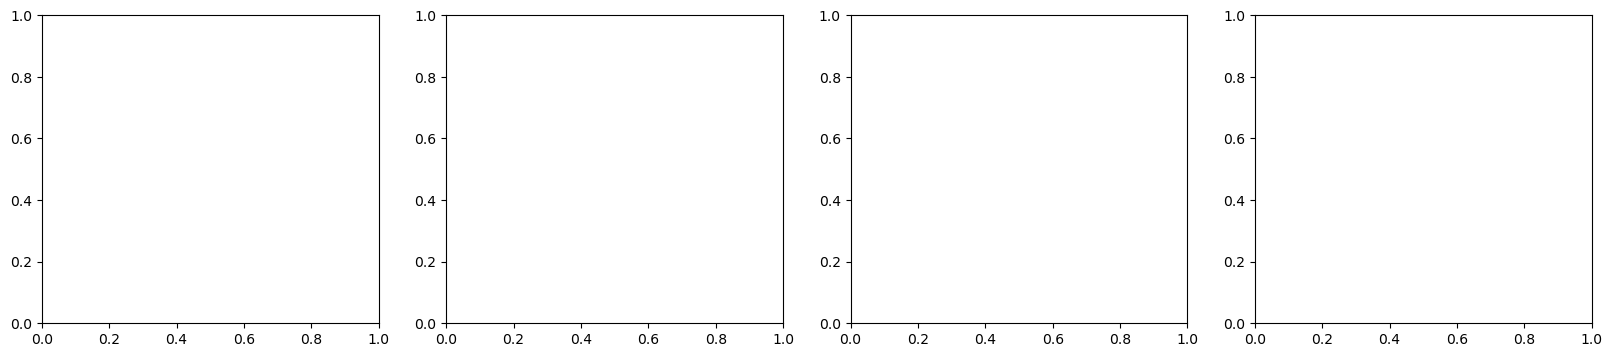

In [20]:
fig, axes = plt.subplots(1,4,figsize=(20,4))
strains = []
t_hist = np.arange(len(lmb_hist))
for t, node_x, F, ax in zip(t_hist, node_x_hist, F_hist, axes):
    E = E_fun(F)
    evals, efuns = jnp.linalg.eigh(E)
    E_11, E_22 = evals.T

    mps = np.maximum(E_11, E_22)
    plotmesh(mesh.cells, mesh.points, mps, title='Max. Princip. Strain [-]', ax=ax); 